# 🛵 Preprocessing Ulasan Ride-Hailing (Gojek · Grab · Maxim)
**Task:** Klasifikasi Subjektif–Objektif  
**Pipeline:** Seleksi Kolom → Lowercase → Cek Awal → Normalisasi → Undersampling → Polish Akhir


## 0. Instalasi & Import

In [1]:
# Instalasi jika belum tersedia
# !pip install pandas scikit-learn

import pandas as pd
import re
from collections import Counter
from sklearn.utils import resample

pd.set_option('display.max_colwidth', 120)


---
## 1. Load Data & Seleksi Kolom
Hanya kolom `review` dan `label` yang digunakan.  
- `label = 0` → **Objektif**  
- `label = 1` → **Subjektif**

In [2]:
df = pd.read_csv('../dataset/subride.csv')

# Tampilkan kolom yang tersedia
print("Kolom tersedia:", df.columns.tolist())
print("Shape awal    :", df.shape)
df.head(3)


Kolom tersedia: ['score', 'app', 'review', 'translated_review', 'label']
Shape awal    : (1338, 5)


,score,app,review,translated_review,label
0,5,Maxim,semoga kedepannya talangan g susah dapatnya karna saya jualan pake jasa maxim yg perlu talangan lama banget kalau ca...,"Hopefully in the future it won’t be so hard to find drivers who are willing to front the money, because I use Maxim ...",1
1,3,Grab,tolong buat pusat grab perbaiki lagi jangan dikit di tangguhkan dan buat para driver jngn gampang melaporkan krna la...,"Please Grab HQ, improve your system — don't suspend drivers so easily, and tell drivers not to report over small thi...",1
2,1,Gojek,woi gojek kalo mau bikin verifikasi minimal bisa depan belakang lah kamera ini depan doang apa si dulu ga pake verif...,"Hey Gojek, if you're going to do face verification, at least use front and back cameras. This one’s just front-facin...",1


In [3]:
# Pilih hanya review + label
df = df[['review', 'label']].copy()
print("Shape setelah seleksi kolom:", df.shape)
df.head(3)


Shape setelah seleksi kolom: (1338, 2)


,review,label
0,semoga kedepannya talangan g susah dapatnya karna saya jualan pake jasa maxim yg perlu talangan lama banget kalau ca...,1
1,tolong buat pusat grab perbaiki lagi jangan dikit di tangguhkan dan buat para driver jngn gampang melaporkan krna la...,1
2,woi gojek kalo mau bikin verifikasi minimal bisa depan belakang lah kamera ini depan doang apa si dulu ga pake verif...,1


---
## 2. Lowercase
Seluruh teks ulasan diubah ke huruf kecil agar konsisten.

In [4]:
df['review'] = df['review'].str.lower().str.strip()

print("Contoh setelah lowercase:")
for r in df['review'].head(3):
    print(" ", r[:100])


Contoh setelah lowercase:
  semoga kedepannya talangan g susah dapatnya karna saya jualan pake jasa maxim yg perlu talangan lama
  tolong buat pusat grab perbaiki lagi jangan dikit di tangguhkan dan buat para driver jngn gampang me
  woi gojek kalo mau bikin verifikasi minimal bisa depan belakang lah kamera ini depan doang apa si du


---
## 3. Pengecekan Awal Kolom Review
Deteksi nilai null, duplikat, baris kosong, dan distribusi label sebelum preprocessing.

In [5]:
print("="*50)
print("STATISTIK AWAL")
print("="*50)
print(f"Total baris      : {len(df):,}")
print(f"Nilai null       : {df['review'].isnull().sum()}")
print(f"Baris kosong     : {(df['review'].str.strip() == '').sum()}")
print(f"Duplikat review  : {df.duplicated(subset=['review']).sum()}")
print()
print("Distribusi Label:")
vc = df['label'].value_counts()
for lbl, cnt in vc.items():
    name = 'Subjektif' if lbl == 1 else 'Objektif'
    pct  = cnt / len(df) * 100
    print(f"  Label {lbl} ({name}): {cnt:,} ({pct:.1f}%)")
print(f"  Rasio imbalance: 1 : {round(vc[1]/vc[0], 2)}")


STATISTIK AWAL
Total baris      : 1,338
Nilai null       : 0
Baris kosong     : 0
Duplikat review  : 0

Distribusi Label:
  Label 1 (Subjektif): 960 (71.7%)
  Label 0 (Objektif): 378 (28.3%)
  Rasio imbalance: 1 : 2.54


In [6]:
# Hapus null, kosong, duplikat awal
df = df.dropna(subset=['review'])
df = df[df['review'].str.strip() != '']
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)

print(f"Shape setelah pembersihan awal: {df.shape}")


Shape setelah pembersihan awal: (1338, 2)


---
## 4. Normalisasi Teks
Pipeline normalisasi 7 tahap:

| Sub-step | Deskripsi |
|----------|-----------|
| 4A | Pisah kata yang disambung dengan konjungsi/preposisi |
| 4B | Ekspansi reduplikasi angka-2 (`tiba2` → `tiba tiba`) |
| 4C | Normalisasi angka + satuan (`15rb` → `15 ribu`) |
| 4D | Pisah angka yang masih menempel ke kata |
| 4E | Ekspansi 70+ kamus singkatan & kata slang |
| 4F | Reduksi huruf berulang (`bangettt` → `banget`) |
| 4G | Hapus karakter non-alfanumerik |


### 4A. Konjungsi/Preposisi yang Disambung

In [7]:
# Contoh masalah kata sambung
examples_concat = [
    "aplikasi ini sangat baiktapi yang bikin jelek itu driver",
    "membantu kami dalam bepergiandengan menggunakan aplikasi",
    "melakukan pemesanansehingga memperlancar waktu tunggu",
]
for e in examples_concat:
    print("BEFORE:", e)
    for conj in ['tapi', 'sehingga', 'dengan', 'karena', 'namun', 'ingin']:
        e = re.sub(r'([a-z]{3,})(' + conj + r')(?=[a-z]{2,}|\s|$)', r'\1 \2', e)
    print("AFTER :", e)
    print()


BEFORE: aplikasi ini sangat baiktapi yang bikin jelek itu driver
AFTER : aplikasi ini sangat baik tapi yang bikin jelek itu driver

BEFORE: membantu kami dalam bepergiandengan menggunakan aplikasi
AFTER : membantu kami dalam bepergian dengan menggunakan aplikasi

BEFORE: melakukan pemesanansehingga memperlancar waktu tunggu
AFTER : melakukan pemesanan sehingga memperlancar waktu tunggu



### 4B. Reduplikasi Angka-2

In [8]:
# Contoh reduplikasi
examples_redup = ["tiba2 driver cancel", "driver2 gak respon", "lama2 gak datang juga"]
for e in examples_redup:
    result = re.sub(r'\b([a-z]{2,})(2)\b',
                    lambda m: m.group(1) + ' ' + m.group(1), e)
    print(f"  {e}  →  {result}")


  tiba2 driver cancel  →  tiba tiba driver cancel
  driver2 gak respon  →  driver driver gak respon
  lama2 gak datang juga  →  lama lama gak datang juga


### 4C. Angka + Satuan

In [9]:
# Contoh normalisasi angka-satuan
examples_num = ["bayar 15rb aja", "nunggu 10mnt", "udah 4x cancel", "harga 4k"]
for e in examples_num:
    e = re.sub(r'(\d+)\s*rb\b', r'\1 ribu', e)
    e = re.sub(r'(\d+)\s*jt\b', r'\1 juta', e)
    e = re.sub(r'(\d+)\s*k\b',  r'\1 ribu', e)
    e = re.sub(r'(\d+)x\b',      r'\1 kali', e)
    e = re.sub(r'(\d+)\s*mnt\b',r'\1 menit', e)
    e = re.sub(r'(\d+)\s*an\b', r'\1 an',   e)
    print(f"  → {e}")


  → bayar 15 ribu aja
  → nunggu 10 menit
  → udah 4 kali cancel
  → harga 4 ribu


### 4E. Kamus Singkatan & Kata Slang

In [10]:
ABBREV_DICT = {
    # ── Pronoun ─────────────────────────────────
    'yg'   : 'yang',
    'sy'   : 'saya',   'sya'  : 'saya',
    'gue'  : 'saya',   'gw'   : 'saya',   'ane': 'saya',
    'lo'   : 'kamu',   'lu'   : 'kamu',   'elu': 'kamu',

    # ── Negasi ──────────────────────────────────
    'ga'   : 'tidak',  'gak'  : 'tidak',  'gk' : 'tidak',
    'tdk'  : 'tidak',  'nggak': 'tidak',  'ngga': 'tidak',
    'engga': 'tidak',  'enggak': 'tidak', 'g'  : 'tidak',
    'gada' : 'tidak ada',
    'gabisa': 'tidak bisa',
    'kagak': 'tidak',  'kaga' : 'tidak',

    # ── Konjungsi/Partikel ───────────────────────
    'tp'   : 'tapi',   'tpi'  : 'tapi',
    'jg'   : 'juga',
    'jgn'  : 'jangan', 'jngan': 'jangan', 'jgnan': 'jangan',

    # ── Kausal ──────────────────────────────────
    'krn'  : 'karena', 'karna': 'karena', 'krna' : 'karena',

    # ── Kondisional ─────────────────────────────
    'klo'  : 'kalau',  'klu'  : 'kalau',  'klw'  : 'kalau',
    'kalo' : 'kalau',

    # ── Intensifier ─────────────────────────────
    'bgt'  : 'banget', 'bngt' : 'banget',
    'sgt'  : 'sangat',

    # ── Kata Kerja/Sifat Tidak Baku ─────────────
    'pake' : 'pakai',  'pke'  : 'pakai',
    'pesen': 'pesan',
    'poto' : 'foto',
    'dapet': 'dapat',  'dpat' : 'dapat',  'dpt'  : 'dapat',
    'nyari': 'mencari',
    'nunggu': 'menunggu', 'nungguin': 'menunggu',
    'bener': 'benar',
    'kyak' : 'seperti','kayak': 'seperti',
    'cancle': 'cancel',
    'sampe': 'sampai', 'ampe' : 'sampai',
    'tau'  : 'tahu',
    'nih'  : 'ini',    'neh'  : 'ini',
    'tuh'  : 'itu',
    'ngomong': 'bicara',
    'ngomel' : 'marah',
    'ngasih' : 'memberi',
    'ngambil': 'mengambil',

    # ── Aplikasi ────────────────────────────────
    'apk'  : 'aplikasi', 'apli': 'aplikasi',

    # ── Komparatif ──────────────────────────────
    'lbh'  : 'lebih',

    # ── Waktu/Aspek ─────────────────────────────
    'sdh'  : 'sudah',  'udah' : 'sudah',  'udh'  : 'sudah',
    'blm'  : 'belum',
    'lg'   : 'lagi',
    'dl'   : 'dulu',
    'skrg' : 'sekarang', 'skrang': 'sekarang',
    'ntr'  : 'nanti',  'nnti' : 'nanti',

    # ── Preposisi ───────────────────────────────
    'dr'   : 'dari',   'dri'  : 'dari',
    'd'    : 'di',
    'dg'   : 'dengan', 'dgn'  : 'dengan',
    'pd'   : 'pada',

    # ── Kuantitas/Kualitas ──────────────────────
    'bnyk' : 'banyak', 'bnyak': 'banyak',
    'msh'  : 'masih',  'msih' : 'masih',
    'krg'  : 'kurang',
    'lncar': 'lancar',

    # ── Pertanyaan ──────────────────────────────
    'gmn'  : 'bagaimana', 'gimana': 'bagaimana',
    'knp'  : 'kenapa',    'knpa'  : 'kenapa',

    # ── Untuk ───────────────────────────────────
    'utk'  : 'untuk',  'tuk'  : 'untuk',

    # ── Bisa ────────────────────────────────────
    'bs'   : 'bisa',

    # ── Lain-lain ───────────────────────────────
    "mengasih": "memberikan",
    "bnget": "banget",
    "yaampun": "astaga",
    "bnyk": "banyak",
    "buset": "astaga",
    "yq": "beberapa",
    "gercep": "cekatan",
    "enggak": "tidak",
    "apaan": "apa",
    "laknat": "hina",
    "jdi": "jadi",
    "yaa": "ya",
    "dlu": "dulu",
    "lEk": "",
    "bin": "dan",
    "utk": "untuk",
    "ujan": "hujan",
    "apakah": "aplikasi",
    "jgn": "jangan",
    "php": "memberi harapan",
    "org": "orang",
    "umr": "upah minimum regional",
    "sdh": "sudah",
    "krn": "karena",
    "fungsifbs": "fungsi tidak bisa",
    "hujanzgak": "hujan tidak",
    "nyantai": "santai",
    "kendarijangan": "kendari jangan",
    "ribukadang": "ribu kadang",
    "ribukami": "ribu kami",
    "bpk": "bapak",
    "hemattidak": "hemat tidak",
    "telfon": "telepon",
    "gmn": "gimana",
    "ramahramah": "ramah-ramah",
    "sya": "saya",
    "pacar": "gocar",
    "grabsemoga": "grab",
    'sm'   : 'sama',
    'aja'  : 'saja',
    'org'  : 'orang',
    'bln'  : 'bulan',
    'thn'  : 'tahun',
    'mnt'  : 'menit',
    'pdahal': 'padahal', 'pdhl' : 'padahal',
    'jmpt' : 'jemput',
    'ny'   : 'nya',
    'dtg'  : 'datang',
    'bkn'  : 'bukan',
    'trs'  : 'terus',  'truss': 'terus',
    'tlong': 'tolong', 'tlg'  : 'tolong',
    'mnta' : 'minta',
    'smg'  : 'semoga',
    'ckp'  : 'cukup',
    'hrus' : 'harus',  'haruss': 'harus',
    'cmn'  : 'cuma',   'cman' : 'cuma',
    'ok'   : 'oke',
    'yaa'  : 'ya',     'yaaa' : 'ya',
    'ky'   : 'seperti', 'kayaknya': 'sepertinya',
    'kntong': 'kantong', 'brsaing': 'bersaing',
    'sb'   : 'sebab',
    'jkt'  : 'jakarta',

    # ── Terima Kasih (berbagai variasi) ─────────
    'makasih'     : 'terima kasih',
    'mksh'        : 'terima kasih',
    'mksih'       : 'terima kasih',
    'trmksh'      : 'terima kasih',
    'trimksh'     : 'terima kasih',
    'trims'       : 'terima kasih',
    'trimakasih'  : 'terima kasih',
    'terimakasih' : 'terima kasih',

    # ── Ekspresi/Slang ──────────────────────────
    'donk' : 'dong',
    'woi'  : 'hei',

    # ── Nama Aplikasi (typo) ─────────────────────
    'maxsim': 'maxim',
    'maxin' : 'maxim',
    'gojk'  : 'gojek',
    'grb'   : 'grab',
    'ojol'  : 'ojek online',
    'goride': 'gojek',

    # ── Typo lainnya ─────────────────────────────
    'cancle': 'cancel',
    'poto'  : 'foto',
}

print(f"Total entri kamus: {len(ABBREV_DICT)}")

# Contoh beberapa entri
sample_items = list(ABBREV_DICT.items())[:10]
for k, v in sample_items:
    print(f"  '{k}' → '{v}'")


Total entri kamus: 170
  'yg' → 'yang'
  'sy' → 'saya'
  'sya' → 'saya'
  'gue' → 'saya'
  'gw' → 'saya'
  'ane' → 'saya'
  'lo' → 'kamu'
  'lu' → 'kamu'
  'elu' → 'kamu'
  'ga' → 'tidak'


### Fungsi Normalisasi Lengkap

In [11]:
# Daftar konjungsi yang sering disambung tanpa spasi
CONJUNCTIONS_TO_SPLIT = ['tapi', 'sehingga', 'dengan', 'karena', 'namun', 'ingin']

def normalize_text(text: str) -> str:
    """
    Normalisasi teks ulasan ride-hailing.
    
    Tahapan:
      4A - Pisah kata sambung (baiktapi → baik tapi)
      4B - Ekspansi reduplikasi-2 (tiba2 → tiba tiba)
      4C - Normalisasi angka-satuan (15rb → 15 ribu)
      4D - Pisah angka-kata menempel (5000ada → 5000 ada)
      4E - Ekspansi kamus singkatan/slang
      4F - Reduksi huruf berulang ≥3x (bangettt → banget)
      4G - Hapus karakter non-alfanumerik
    """
    if not isinstance(text, str) or not text.strip():
        return text

    # Hapus URL & email
    text = re.sub(r'https?://\S+|www\.\S+|\S+@\S+', '', text)

    # ── 4A. Pisah konjungsi yang disambung ──────────────────────────────────
    for conj in CONJUNCTIONS_TO_SPLIT:
        # Contoh: "baiktapi" → "baik tapi"
        text = re.sub(
            r'([a-z]{3,})(' + conj + r')(?=[a-z]{2,}|\s|$)',
            r'\1 \2', text
        )

    # ── 4B. Reduplikasi angka-2 ─────────────────────────────────────────────
    # Contoh: tiba2 → tiba tiba, driver2 → driver driver
    def expand_redup(m):
        w = m.group(1)
        return w + ' ' + w if not w.isdigit() else m.group(0)
    text = re.sub(r'\b([a-z]{2,})(2)\b', expand_redup, text)

    # ── 4C. Normalisasi angka + satuan ──────────────────────────────────────
    text = re.sub(r'(\d+)\s*rb\b',  r'\1 ribu',  text)  # 15rb  → 15 ribu
    text = re.sub(r'(\d+)\s*jt\b',  r'\1 juta',  text)  # 5jt   → 5 juta
    text = re.sub(r'(\d+)\s*k\b',   r'\1 ribu',  text)  # 4k    → 4 ribu
    text = re.sub(r'(\d+)x\b',       r'\1 kali',  text)  # 10x   → 10 kali
    text = re.sub(r'(\d+)\s*mnt\b', r'\1 menit', text)  # 5mnt  → 5 menit
    text = re.sub(r'(\d+)\s*an\b',  r'\1 an',    text)  # 7an   → 7 an

    # ── 4D. Pisah angka-kata yang masih menempel ────────────────────────────
    text = re.sub(r'(\d+)([a-z]{2,})', r'\1 \2', text)
    text = re.sub(r'([a-z]{2,})(\d+)', r'\1 \2', text)

   # ── 4E. Hapus karakter non-alfanumerik
    text = re.sub(r'[^a-z0-9\s.,!?]', ' ', text)

    # ── 4F. Reduksi huruf berulang ≥3x menjadi 1
    text = re.sub(r'([a-z])\1{2,}', r'\1', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    # ── 4G. Ekspansi kamus singkatan (token per token)
    tokens = text.split()
    normalized = []

    for tok in tokens:

        clean = re.sub(r'[^a-z0-9]', '', tok)

        if clean in ABBREV_DICT:
            normalized.append(ABBREV_DICT[clean])
        else:
            normalized.append(tok)

    text = ' '.join(normalized)

    # Rapikan spasi lagi
    text = re.sub(r'\s+', ' ', text).strip()

    return text


### Uji Normalisasi pada Contoh Nyata

In [12]:
test_cases = [
    "makin mahal ongkosnya tapi katanya bayar buat abang ojolnya ga naik",
    "pelayanan gocar makin buruk pesen gocar banyak drivernya gak respon kadang malah mnjauh dr lokasi tp gk mau cancel",
    "trmksh bnyak driver sangat ramah baiktrmksh sdh membantu mngendong ank smp k rmh",
    "nunggu driver2 tapi gada yg mau cancel2 akhirnya aplikasi di restart",
    "bayar 15rb aja udh bisa ke mana mana tiba2 harga naik 3x lipat gak masuk akal bgt",
    "aplikasi maxsim ini sangat membantu tp driver ny kadang telat bgt",
]

for tc in test_cases:
    print("BEFORE:", tc)
    print("AFTER :", normalize_text(tc))
    print()


BEFORE: makin mahal ongkosnya tapi katanya bayar buat abang ojolnya ga naik
AFTER : makin mahal ongkosnya tapi katanya bayar buat abang ojolnya tidak naik

BEFORE: pelayanan gocar makin buruk pesen gocar banyak drivernya gak respon kadang malah mnjauh dr lokasi tp gk mau cancel
AFTER : pelayanan gocar makin buruk pesan gocar banyak drivernya tidak respon kadang malah mnjauh dari lokasi tapi tidak mau cancel

BEFORE: trmksh bnyak driver sangat ramah baiktrmksh sdh membantu mngendong ank smp k rmh
AFTER : terima kasih banyak driver sangat ramah baiktrmksh sudah membantu mngendong ank smp k rmh

BEFORE: nunggu driver2 tapi gada yg mau cancel2 akhirnya aplikasi di restart
AFTER : menunggu driver driver tapi tidak ada yang mau cancel cancel akhirnya aplikasi di restart

BEFORE: bayar 15rb aja udh bisa ke mana mana tiba2 harga naik 3x lipat gak masuk akal bgt
AFTER : bayar 15 ribu saja sudah bisa ke mana mana tiba tiba harga naik 3 kali lipat tidak masuk akal banget

BEFORE: aplikasi maxsim 

### Terapkan Normalisasi ke Seluruh Dataset

In [13]:
df['review'] = df['review'].apply(normalize_text)

print("Normalisasi selesai!")
print(f"Shape : {df.shape}")

# Preview hasil
df[['review', 'label']].sample(5, random_state=42)


Normalisasi selesai!
Shape : (1338, 2)


,review,label
764,driver pilihpilih pembayaran menggunakan ewallet tidak ada yang mau tapi kalau pakai tunai minta lebih susah juga me...,1
887,saya sebagai customer lama lama kecewa sama ini aplikasimau pakai layanannya jadi segan kasianan ke driver saya paka...,1
890,astaga saya menunggu pesenan gacoan saya dari jam 1049 sampai jam 1 belum ke anter perkara belum ada driver tidak ad...,0
1293,kalau tidak niat memberi promo tidak usah sok masang promo buat user ujungnya tidak dapat driver stelah berjam menunggu,1
259,tolong driver grab untuk diedukasi terkait tarif karena ngeluh terus n menjebak penumpang minta tambhan ongkos 20 ri...,0


---
## 5. Pengecekan Ulang Pasca Normalisasi
Setelah normalisasi, beberapa teks yang sebelumnya berbeda bisa menjadi identik → perlu deduplikasi ulang.

In [14]:
print("="*50)
print("PENGECEKAN PASCA NORMALISASI")
print("="*50)
before = len(df)
df = df.drop_duplicates(subset=['review'])
df = df[df['review'].str.strip() != ''].dropna(subset=['review'])
df = df.reset_index(drop=True)
after = len(df)

print(f"Baris sebelum deduplikasi : {before:,}")
print(f"Duplikat baru ditemukan   : {before - after}")
print(f"Baris setelah bersih      : {after:,}")
print()
print("Distribusi label setelah normalisasi:")
vc = df['label'].value_counts()
for lbl, cnt in vc.items():
    name = 'Subjektif' if lbl == 1 else 'Objektif'
    print(f"  Label {lbl} ({name}): {cnt:,}")


PENGECEKAN PASCA NORMALISASI
Baris sebelum deduplikasi : 1,338
Duplikat baru ditemukan   : 0
Baris setelah bersih      : 1,338

Distribusi label setelah normalisasi:
  Label 1 (Subjektif): 960
  Label 0 (Objektif): 378


In [15]:
# Cek apakah masih ada singkatan yang lolos
sisa_check = {
    'yg': 'yang', 'tp': 'tapi', 'gak': 'tidak', 'gk': 'tidak',
    'krn': 'karena', 'klo': 'kalau', 'bgt': 'banget', 'jg': 'juga',
    'apk': 'aplikasi', 'sdh': 'sudah', 'blm': 'belum', 'sampe': 'sampai',
    'trmksh': 'terima kasih', 'makasih': 'terima kasih',
}
print("Cek sisa singkatan yang masih lolos:")
found_any = False
for abbrev in sisa_check:
    count = df['review'].str.contains(r'\b' + abbrev + r'\b', regex=True).sum()
    if count > 0:
        print(f"  ⚠  '{abbrev}' masih ada di {count} baris")
        found_any = True
if not found_any:
    print("  ✓ Tidak ada singkatan utama yang lolos!")


Cek sisa singkatan yang masih lolos:
  ✓ Tidak ada singkatan utama yang lolos!


---
## 6. Undersampling
Dataset tidak seimbang: Label 1 (Subjektif) jauh lebih banyak dari Label 0 (Objektif).  
Solusi: **Random Undersampling** — kurangi sampel label mayoritas hingga sama dengan minoritas.

In [16]:
from sklearn.utils import resample

df_objektif  = df[df['label'] == 0]   # minoritas
df_subjektif = df[df['label'] == 1]   # mayoritas

print(f"Sebelum undersampling:")
print(f"  Label 0 (Objektif)  : {len(df_objektif):,}")
print(f"  Label 1 (Subjektif) : {len(df_subjektif):,}")
print(f"  Rasio               : 1 : {round(len(df_subjektif)/len(df_objektif), 2)}")


Sebelum undersampling:
  Label 0 (Objektif)  : 378
  Label 1 (Subjektif) : 960
  Rasio               : 1 : 2.54


In [17]:
# Undersample label 1 → sesuaikan dengan jumlah label 0
df_subjektif_down = resample(
    df_subjektif,
    replace=False,          # tanpa penggantian
    n_samples=len(df_objektif),
    random_state=42
)

# Gabung dan acak
df = pd.concat([df_subjektif_down, df_objektif])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Setelah undersampling:")
vc = df['label'].value_counts()
for lbl, cnt in vc.items():
    name = 'Subjektif' if lbl == 1 else 'Objektif'
    print(f"  Label {lbl} ({name}): {cnt:,}")
print(f"  Rasio               : 1 : 1.0 ✓")
print(f"  Total               : {len(df):,}")


Setelah undersampling:
  Label 0 (Objektif): 378
  Label 1 (Subjektif): 378
  Rasio               : 1 : 1.0 ✓
  Total               : 756


---
## 7. Simpan Hasil

In [18]:
output_path = 'subride_clean.csv'
df.to_csv(output_path, index=False)
print(f"✓ Dataset disimpan → {output_path}")
print(f"  Shape final : {df.shape}")


✓ Dataset disimpan → subride_clean.csv
  Shape final : (756, 2)


---
## 8. Visualisasi & Ringkasan Akhir

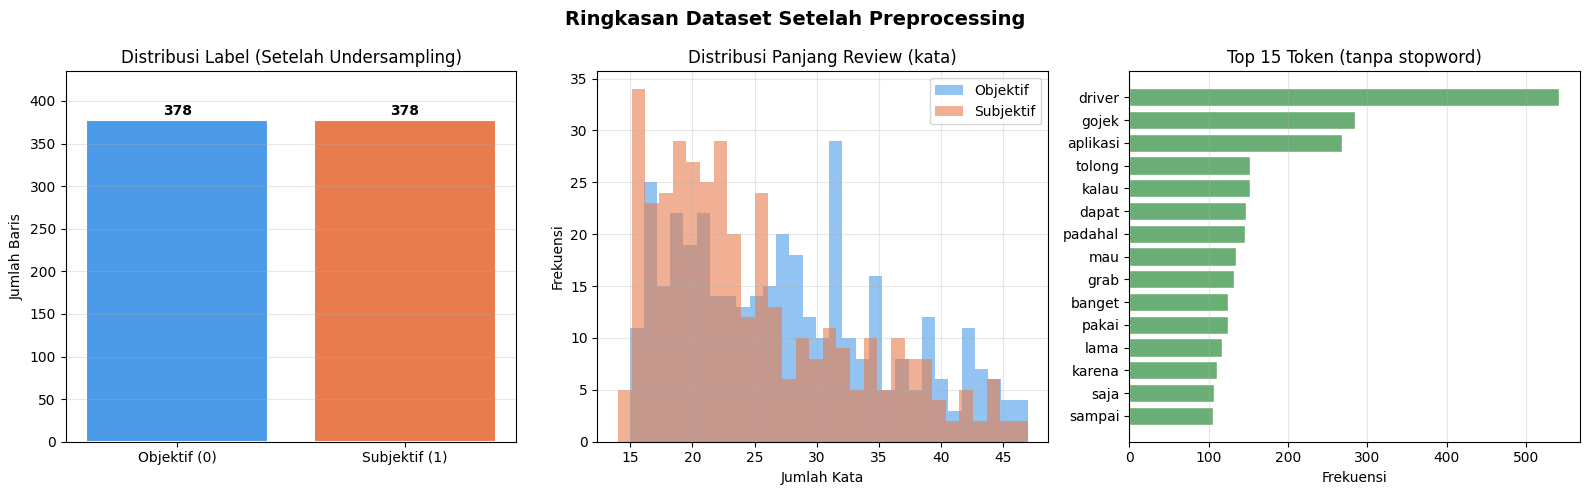

Plot disimpan → preprocessing_summary.png


In [19]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Ringkasan Dataset Setelah Preprocessing', fontsize=14, fontweight='bold')

    # Plot 1 – Distribusi Label
    ax1 = axes[0]
    colors = ['#4C9BE8', '#E87C4C']
    bars = ax1.bar(['Objektif (0)', 'Subjektif (1)'],
                   [len(df[df['label']==0]), len(df[df['label']==1])],
                   color=colors, edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
    ax1.set_title('Distribusi Label (Setelah Undersampling)')
    ax1.set_ylabel('Jumlah Baris')
    ax1.set_ylim(0, max(len(df[df['label']==0]), len(df[df['label']==1])) * 1.15)
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2 – Distribusi Panjang Review (histogram)
    ax2 = axes[1]
    lengths_obj = df[df['label']==0]['review'].str.split().str.len()
    lengths_sub = df[df['label']==1]['review'].str.split().str.len()
    ax2.hist(lengths_obj, bins=30, alpha=0.6, color='#4C9BE8', label='Objektif')
    ax2.hist(lengths_sub, bins=30, alpha=0.6, color='#E87C4C', label='Subjektif')
    ax2.set_title('Distribusi Panjang Review (kata)')
    ax2.set_xlabel('Jumlah Kata')
    ax2.set_ylabel('Frekuensi')
    ax2.legend()
    ax2.grid(alpha=0.3)

    # Plot 3 – Top 15 Token
    ax3 = axes[2]
    all_tok = Counter()
    stopwords = {'yang', 'di', 'dan', 'saya', 'tidak', 'ini', 'ada', 'ke',
                 'untuk', 'dengan', 'atau', 'pada', 'dari', 'tapi', 'juga',
                 'bisa', 'sudah', 'nya', 'sama', 'itu', 'dalam', 'lagi'}
    for r in df['review']:
        all_tok.update([t for t in r.split() if t not in stopwords and len(t) > 2])
    top15 = all_tok.most_common(15)
    words, freqs = zip(*top15)
    ax3.barh(list(words)[::-1], list(freqs)[::-1], color='#6BAE75', edgecolor='white')
    ax3.set_title('Top 15 Token (tanpa stopword)')
    ax3.set_xlabel('Frekuensi')
    ax3.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('preprocessing_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot disimpan → preprocessing_summary.png")

except ImportError:
    print("matplotlib tidak tersedia, skip visualisasi.")


In [20]:
# Ringkasan statistik akhir
print("=" * 60)
print("RINGKASAN FINAL PREPROCESSING")
print("=" * 60)
print(f"  Total baris    : {len(df):,}")
print(f"  Label 0        : {(df['label']==0).sum():,} (Objektif)")
print(f"  Label 1        : {(df['label']==1).sum():,} (Subjektif)")
print(f"  Rasio          : 1:1 (seimbang)")
print(f"  Null           : {df.isnull().sum().sum()}")
print(f"  Duplikat       : {df.duplicated().sum()}")
print(f"  Avg kata/review: {df['review'].str.split().str.len().mean():.1f}")
print(f"  Min kata/review: {df['review'].str.split().str.len().min()}")
print(f"  Max kata/review: {df['review'].str.split().str.len().max()}")
print()
print("Sampel Akhir (masing-masing 3 label):")
for lbl in [0, 1]:
    name = 'OBJEKTIF' if lbl == 0 else 'SUBJEKTIF'
    print(f"\n  [{name}]")
    for r in df[df['label']==lbl]['review'].sample(3, random_state=7):
        print(f"    • {r[:100]}")


RINGKASAN FINAL PREPROCESSING
  Total baris    : 756
  Label 0        : 378 (Objektif)
  Label 1        : 378 (Subjektif)
  Rasio          : 1:1 (seimbang)
  Null           : 0
  Duplikat       : 0
  Avg kata/review: 26.3
  Min kata/review: 14
  Max kata/review: 47

Sampel Akhir (masing-masing 3 label):

  [OBJEKTIF]
    • bagus ih tapi tolong di permudah cari titik maps nya titik lokasi nya susah banget
    • saya melakukan penarikan sudah lebih dari 6 hari dana saya belum masuk setelah di telfn csnya malah 
    • aplikasi gojek tolol gua lagi zoomin peta malah balik zoom out gitu saja terus bikin darah orang nai

  [SUBJEKTIF]
    • b1 menyala bos qu aplikasi gojek sekarang cuma di bikin akaln demi meraup keuntungan yang besar suda
    • sudah lama tidak pakai grab pas liat pembayaran bisa pakai qris aku jd pakai grab lagi eh sekarang m
    • jangan download mending maxcim lebih murah gojek mahal kadang kata driver nya suka korupsi kita baya
